### Разбор архитектуры Word2Vec: CBOW (Continuous Bag-of-Words) и Skip-Gram с Negative Sampling

- Загрузка и предобработка корпуса новостей
- Обучение моделей
- Визуализация
- Анализ эмбеддингов

---
# Домашнее задание (Word2Vec Advanced)

**Задание состоит из двух частей:**

1.  **Практическая часть: Обучение и анализ.**
    *   Обучите модели CBOW и Skip-Gram с Negative Sampling на предоставленном корпусе новостей, используя код из ноутбука.
    *   Для одной из моделей (на ваш выбор) проведите визуализацию эмбеддингов (как в п. 7.1) для 15-20 слов, относящихся к разным тематикам (например, политика, спорт, медицина, культура).
    *   **Проанализируйте** получившийся график: образуют ли слова из одной темы кластеры? Есть ли слова, которые, на ваш взгляд, находятся не в своем кластере? Почему это могло произойти?

2.  **Аналитическая часть: Эксперимент с гиперпараметрами.**
    *   Выберите одну из моделей (например, Skip-Gram) и один набор тестовых слов (например, `['коронавирус', 'инфекция', 'болезнь', 'вакцина']`).
    *   Проведите небольшое исследование, как изменение следующих гиперпараметров влияет на качество получаемых эмбеддингов (используйте косинусное сходство или аналогии как метрику):
        *   **Размер окна (window size):** Попробуйте значения 1, 3, 5.
        *   **Размерность эмбеддинга (embedding size):** Попробуйте значения 50, 100, 200.
    *   **Опишите** свои наблюдения. Какой размер окна лучше подходит для поиска тематически близких слов, а какой — для синтаксически близких? Влияет ли размерность на скорость обучения и на качество?

**Формат сдачи:**
Оформите отчет (в формате `.ipynb` или `.pdf`), который включает:
*   Краткое описание проделанной работы.
*   Графики из п.1 и ваш анализ к ним.
*   Таблицу или графики, иллюстрирующие влияние гиперпараметров из п.2, и ваши выводы.

# Практическая часть: обучение и анализ

## 1. Загрузка библиотек

In [ ]:
# для цветного вывода в консоль (опционально)
# для морфологического анализа (PoS-тэггинг)
!pip install colorama natasha -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 38.1 MB/s eta 0:00:00


In [ ]:
from colorama import Fore, Style
import json
import random

from natasha import NewsMorphTagger, NewsEmbedding, Doc, Segmenter

import re
from collections import defaultdict
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD, Adam
from torch.utils.data import DataLoader, Dataset
import copy

from sklearn.decomposition import TruncatedSVD, PCA
import matplotlib.pyplot as plt

# Для корректного отображения графиков в Colab
%matplotlib inline

# Определяем устройство один раз глобально
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{Fore.GREEN}Используется устройство: {device}{Style.RESET_ALL}")

Используется устройство: cuda


## 2. Загрузка и подготовка корпуса

Мы будем работать с корпусом новостей [Московского комсомольца](https://github.com/vifirsanova/W2V/blob/main/corpus.json). Он уже собран и подготовлен.

In [ ]:
# загружаем корпус
!wget -q --show-progress https://raw.githubusercontent.com/vifirsanova/W2V/main/corpus.json

with open('corpus.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"{Fore.GREEN}Корпус загружен. Пример записи:{Style.RESET_ALL}")
data['data'][0]

corpus.json         100%[===================>]  87.84M   142MB/s    in 0.6s    
Корпус загружен. Пример записи:


{'link': 'https://www.mk.ru/social/2020/03/31/minobrnauki-pereneslo-vstupitelnye-ekzameny-v-vuzy-izza-koronavirusa.html',
 'title': 'Минобрнауки решило перенести вступительные экзамены в вузы из-за коронавируса',
 'date': '31.03.2020',
 'time': '09:11',
 'rubric': 'Общество',
 'text': '\nВ Минобрнауки РФ приняли решение перенести даты вступительных экзаменов в вузы из-за коронавируса, заявил глава ведомства Валерий Фальков в интервью «Россия 24».\nОн отметил, что в этом году число бюджетных мест было увеличено на 34 тысячи. Сейчас начался экономический спад, но менять стратегию в министерстве не намерены.\nРешение об увеличении бюджетных мест в вузах связано с ростом числа выпускников школ. Будет увеличено число мест на педагогическом и медицинском направлениях. Большой запрос на бюджетные места у регионов, подчеркнул Фальков.\nРанее власти перенесли даты ЕГЭ и ОГЭ.\nЧитайте также:\xa0Скворцова похвалила российский препарат от коронавируса\n\xa0\n\n'}

In [ ]:
# извлекаем тексты и перемешиваем
full_dataset = [item['text'] for item in data['data']]
random.shuffle(full_dataset)

# разделяем на train/val
split = int(0.8 * len(full_dataset))
train_texts = full_dataset[:split]
val_texts = full_dataset[split:]

# Урезаем размер выборки для быстрого обучения
TRAIN_SAMPLE_SIZE = 10000  # вместо 36736
VAL_SAMPLE_SIZE = 2000    # вместо 9184

train_texts = train_texts[:TRAIN_SAMPLE_SIZE]
val_texts = val_texts[:VAL_SAMPLE_SIZE]

print(f"{Fore.GREEN}Урезанная обучающая выборка: {len(train_texts)} документов{Style.RESET_ALL}")
print(f"{Fore.GREEN}Урезанная проверочная выборка: {len(val_texts)} документов{Style.RESET_ALL}")
print(f"{Fore.GREEN}\nПример текста:{Style.RESET_ALL}\n{train_texts[0][:500]}...")

Урезанная обучающая выборка: 10000 документов
Урезанная проверочная выборка: 2000 документов

Пример текста:

Власти РФ внимательно следят за расследованием дела об убийстве посла России в Турции Андрея Карлова. Об этом рассказал представитель Кремля Дмитрий Песков.
По его словам, в Москве хотят быть уверенными, что "заказчики и исполнители убийства российского посла в Турции будут найдены и наказаны" по закону.
Кроме того, Песков отказался комментировать внутренние процессы, которые связаны с судебной системой и гособвинением в Турции. Кроме того, он не знает, занимаются ли российские спецслужбы этим ...


## 3. Морфологический анализ (PoS-tagging)

Хотя для Word2Vec разметка не обязательна, она поможет нам позже при анализе коллокатов. Мы воспользуемся библиотекой `natasha`.

In [ ]:
# создаем объекты Doc
train_docs = [Doc(text) for text in train_texts[:2000]]
val_docs = [Doc(text) for text in val_texts[:400]]

# сегментируем на токены и предложения
segmenter = Segmenter()
for doc in train_docs + val_docs:
    doc.segment(segmenter)

# тэггируем части речи
morph_tagger = NewsMorphTagger(NewsEmbedding())
for doc in train_docs + val_docs:
    doc.tag_morph(morph_tagger)

print(f"{Fore.GREEN}Пример размеченного токена:{Style.RESET_ALL}")
tok = val_docs[0].tokens[0]
print(f"Слово: {tok.text}, PoS: {tok.pos}, Морфология: {tok.feats}")

Пример размеченного токена:
Слово: США, PoS: PROPN, Морфология: {'Animacy': 'Inan', 'Case': 'Nom', 'Gender': 'Masc', 'Number': 'Plur'}


In [ ]:
# сохраним разметку для будущих задач
def build_tag_dict(docs):
    tag_dict = {}
    for doc in docs:
        for tok in doc.tokens:
            if tok.text not in tag_dict:
                tag_dict[tok.text] = (tok.pos, tok.feats)
    return tag_dict

train_tag_dict = build_tag_dict(train_docs)
val_tag_dict = build_tag_dict(val_docs)

print(f"{Fore.GREEN}Размер словаря тегов: {len(train_tag_dict)}{Style.RESET_ALL}")

Размер словаря тегов: 38586


## 4. Токенизация и построение словаря

Теперь перейдем к основной предобработке для модели.

In [ ]:
# Загружаем стоп-слова
!wget -q https://raw.githubusercontent.com/vifirsanova/W2V/main/swl.txt
with open('swl.txt', 'r', encoding='utf-8') as f:
    stop_words = set([line.strip() for line in f])

print(f"{Fore.GREEN}Загружено {len(stop_words)} стоп-слов. Пример: {list(stop_words)[:5]}{Style.RESET_ALL}")

# Токенизатор
def tokenize(text):
    """Разбивает текст на токены (слова и цифры), приводит к нижнему регистру."""
    return re.findall(r'[\w\d]+', text.lower())

train_tokenized = [tokenize(text) for text in train_texts]
val_tokenized = [tokenize(text) for text in val_texts]

print(f"{Fore.GREEN}Пример токенизации:{Style.RESET_ALL}")
print(' '.join(train_tokenized[0][:15]))

Загружено 925 стоп-слов. Пример: ['', 'хто', '_', ',', 'как-либо']
Пример токенизации:
власти рф внимательно следят за расследованием дела об убийстве посла россии в турции андрея карлова


In [ ]:
def build_vocab(tokenized_corpus, stop_words, pad_word='<PAD>'):
    """
    Строит словарь на основе токенизированного корпуса.
    Возвращает:
        word2id: соответствие слово -> индекс
        word_doc_freq: частотность слов в корпусе (количество документов, где слово встретилось)
    """
    doc_freq = defaultdict(int)
    for text in tokenized_corpus:
        # считаем по документо-частоте, а не по частоте вхождений
        for word in set(text):
            if word not in stop_words:
                doc_freq[word] += 1

    # удаляем редкие слова (встретились только в 1 документе)
    doc_freq = {w: cnt for w, cnt in doc_freq.items() if cnt > 1}

    # сортируем по убыванию частоты
    sorted_vocab = sorted(doc_freq.items(), key=lambda x: -x[1])
    words = [pad_word] + [w for w, _ in sorted_vocab]

    word2id = {w: i for i, w in enumerate(words)}
    word_doc_freq = np.array([0] + [cnt for _, cnt in sorted_vocab], dtype='float32')
    # нормируем, чтобы получить вероятность встретить слово в случайном документе
    word_doc_freq /= len(tokenized_corpus)

    return word2id, word_doc_freq

word2id, word_doc_freq = build_vocab(train_tokenized, stop_words)

vocab_size = len(word2id)
print(f"{Fore.GREEN}Размер словаря: {vocab_size}{Style.RESET_ALL}")
print(f"{Fore.GREEN}Первые 10 слов словаря:{Style.RESET_ALL}")
list(word2id.items())[:10]

Размер словаря: 40348
Первые 10 слов словаря:


[('<PAD>', 0),
 ('этом', 1),
 ('а', 2),
 ('россии', 3),
 ('ранее', 4),
 ('заявил', 5),
 ('словам', 6),
 ('время', 7),
 ('будет', 8),
 ('коронавируса', 9)]

### 4.1 Векторизация

Превращаем слова в их индексы в словаре.

In [ ]:
def texts_to_ids(tokenized_corpus, word2id):
    """Заменяет слова на их индексы. Незнакомые слова игнорируются."""
    return [[word2id[token] for token in text if token in word2id] for text in tokenized_corpus]

train_ids = texts_to_ids(train_tokenized, word2id)
val_ids = texts_to_ids(val_tokenized, word2id)

print(f"{Fore.GREEN}Исходный текст:{Style.RESET_ALL} {train_tokenized[0][:5]}")
print(f"{Fore.GREEN}Числовые ID:{Style.RESET_ALL} {train_ids[0][:5]}")
print(f"{Fore.GREEN}Обратно по словарю:{Style.RESET_ALL} {[list(word2id.keys())[i] for i in train_ids[0][:5]]}")

Исходный текст: ['власти', 'рф', 'внимательно', 'следят', 'за']
Числовые ID: [39, 18, 3152, 6634, 8178]
Обратно по словарю: ['власти', 'рф', 'внимательно', 'следят', 'расследованием']


## 5. Датасет и подготовка данных для CBOW

CBOW учится предсказывать центральное слово по его контексту. Нам нужно создать пары (контекст, цель).
**Контекст** — это набор слов вокруг цели. **Цель** — центральное слово.

In [ ]:
# Гиперпараметры
CONTEXT_SIZE = 2  # Количество слов С КАЖДОЙ стороны от центрального. Всего контекст = 2*CONTEXT_SIZE
EMBEDDING_DIM = 100
EPOCHS_CBOW = 2  # Уменьшили с 5 до 2

class CBOWDataset(Dataset):
    def __init__(self, data_ids, context_size):
        """
        data_ids: список текстов, где каждый текст - список ID токенов.
        context_size: сколько слов брать слева и справа.
        """
        self.pairs = []  # ( [id_контекстных_слов], id_целевого_слова )
        for text in data_ids:
            if len(text) < 2*context_size + 1:
                continue
            for i in range(context_size, len(text) - context_size):
                context = text[i-context_size:i] + text[i+1:i+context_size+1]
                target = text[i]
                self.pairs.append( (context, target) )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        context, target = self.pairs[idx]
        return torch.tensor(context, dtype=torch.long), torch.tensor(target, dtype=torch.long)

# Создаем датасеты
cbow_train_dataset = CBOWDataset(train_ids, CONTEXT_SIZE)
cbow_val_dataset = CBOWDataset(val_ids, CONTEXT_SIZE)

print(f"{Fore.GREEN}Количество обучающих примеров для CBOW: {len(cbow_train_dataset)}{Style.RESET_ALL}")
print(f"{Fore.GREEN}Пример: контекст {cbow_train_dataset[0][0].tolist()} -> цель {cbow_train_dataset[0][1].item()}{Style.RESET_ALL}")

Количество обучающих примеров для CBOW: 960716
Пример: контекст [39, 18, 6634, 8178] -> цель 3152


### 5.1 Модель CBOW

In [ ]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(CBOW, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # Простой линейный слой для предсказания слова по среднему контекстному вектору
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, context_words):
        # context_words: (batch_size, 2*CONTEXT_SIZE)
        embeds = self.embeddings(context_words)  # (batch_size, 2*CONTEXT_SIZE, emb_dim)
        # Усредняем эмбеддинги контекстных слов
        averaged = torch.mean(embeds, dim=1)    # (batch_size, emb_dim)
        out = self.linear(averaged)             # (batch_size, vocab_size)
        log_probs = F.log_softmax(out, dim=1)
        return log_probs

    def get_word_vector(self, word_idx):
        """Возвращает вектор для заданного индекса слова."""
        return self.embeddings(torch.tensor([word_idx])).detach().cpu().numpy()[0]

In [ ]:
# Функция для обучения с поддержкой CUDA и ограничением батчей
def train_cbow(model, train_loader, val_loader, epochs, lr=0.001, device='cpu', max_batches=500):
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.NLLLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = 0

        for i, (context, target) in enumerate(train_loader):
            if i >= max_batches:  # Ограничиваем количество батчей
                break

            context, target = context.to(device), target.to(device)

            optimizer.zero_grad()
            log_probs = model(context)
            loss = criterion(log_probs, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            batch_count += 1

        # Валидация (тоже ограничиваем)
        model.eval()
        val_loss = 0
        val_count = 0
        with torch.no_grad():
            for i, (context, target) in enumerate(val_loader):
                if i >= max_batches // 2:  # Меньше батчей для валидации
                    break
                context, target = context.to(device), target.to(device)
                log_probs = model(context)
                loss = criterion(log_probs, target)
                val_loss += loss.item()
                val_count += 1

        print(f"Epoch {epoch+1}, Train Loss: {total_loss/batch_count:.4f}, Val Loss: {val_loss/val_count:.4f}")

    return model

# Инициализация и обучение CBOW
cbow_model = CBOW(vocab_size, EMBEDDING_DIM)

# Оптимизация DataLoader
train_loader_cbow = DataLoader(
    cbow_train_dataset,
    batch_size=256,  # Увеличили batch_size
    shuffle=True,
    num_workers=2,  # Параллельная загрузка
    pin_memory=True  # Ускоряет передачу на GPU
)

val_loader_cbow = DataLoader(
    cbow_val_dataset,
    batch_size=256,
    num_workers=2,
    pin_memory=True
)

# Обучаем с ограничением батчей
cbow_model = train_cbow(cbow_model, train_loader_cbow, val_loader_cbow,
                        epochs=EPOCHS_CBOW, device=device, max_batches=500)

Epoch 1, Train Loss: 7.4654, Val Loss: 5.6117
Epoch 2, Train Loss: 5.8455, Val Loss: 5.2701


## 6. Skip-Gram with Negative Sampling (SGNS)

Skip-Gram предсказывает контекст по центральному слову.

Negative Sampling упрощает задачу, превращая ее в бинарную классификацию: учим модель отличать реальные пары (слово, контекст) от случайных (шумовых).

Для эффективности мы не будем генерировать все возможные пары (центр, контекст) заранее. Мы сделаем это *на лету* внутри датасета.

In [ ]:
# Гиперпараметры для Skip-Gram
WINDOW_SIZE = 2          # Размер окна (с каждой стороны)
NEG_SAMPLES = 5          # Количество негативных примеров на один позитивный
EMB_DIM_SG = 100
EPOCHS_SG = 1  # Уменьшили до 1 эпохи

class SkipGramDataset(Dataset):
    def __init__(self, data_ids, window_size, neg_samples, vocab_size):
        self.data_ids = data_ids
        self.window_size = window_size
        self.neg_samples = neg_samples
        self.vocab_size = vocab_size
        self.pairs = []  # список (центр, контекст)
        for text in data_ids:
            text_len = len(text)
            for i, target in enumerate(text):
                # Определяем динамическое окно
                start = max(0, i - window_size)
                end = min(text_len, i + window_size + 1)
                for j in range(start, end):
                    if j == i: continue
                    self.pairs.append( (target, text[j]) )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        center, pos_context = self.pairs[idx]
        # Генерируем негативные примеры
        neg_contexts = torch.randint(1, self.vocab_size, (self.neg_samples,))
        return (torch.tensor(center, dtype=torch.long),
                torch.tensor(pos_context, dtype=torch.long),
                neg_contexts)

# Уменьшаем датасет для Skip-Gram (берем только первые 1000 документов)
sg_dataset = SkipGramDataset(train_ids[:1000], WINDOW_SIZE, NEG_SAMPLES, vocab_size)
print(f"{Fore.GREEN}Урезанный датасет для Skip-Gram: {len(sg_dataset)} пар{Style.RESET_ALL}")

Урезанный датасет для Skip-Gram: 402248 пар


In [ ]:
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramNegSampling, self).__init__()
        self.center_emb = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.context_emb = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Инициализация (Xavier)
        nn.init.xavier_uniform_(self.center_emb.weight)
        nn.init.xavier_uniform_(self.context_emb.weight)
        # Обнуляем паддинг
        self.center_emb.weight.data[0] = 0
        self.context_emb.weight.data[0] = 0

    def forward(self, center, pos_context, neg_contexts):
        """
        center: (batch_size,)
        pos_context: (batch_size,)
        neg_contexts: (batch_size, neg_samples)
        """
        center_vec = self.center_emb(center)  # (batch, emb_dim)
        pos_vec = self.context_emb(pos_context)  # (batch, emb_dim)
        neg_vecs = self.context_emb(neg_contexts)  # (batch, neg_samples, emb_dim)

        # Положительное сходство (чем больше, тем лучше)
        pos_score = torch.sum(center_vec * pos_vec, dim=1)  # (batch,)
        pos_loss = -F.logsigmoid(pos_score).mean()

        # Отрицательное сходство (чем меньше, тем лучше)
        neg_score = torch.bmm(neg_vecs, center_vec.unsqueeze(2)).squeeze()  # (batch, neg_samples)
        neg_loss = -F.logsigmoid(-neg_score).mean()

        return pos_loss + neg_loss

    def get_center_vector(self, word_idx):
        return self.center_emb(torch.tensor([word_idx])).detach().cpu().numpy()[0]

In [ ]:
def train_skipgram(model, dataset, epochs, batch_size=512, lr=0.01, device='cpu', max_batches=300):
    model.to(device)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                       collate_fn=lambda x: list(zip(*x)), num_workers=2, pin_memory=True)
    optimizer = Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = 0

        for i, batch in enumerate(loader):
            if i >= max_batches:
                break

            centers, pos_contexts, neg_contexts = batch
            centers = torch.stack(centers).to(device)
            pos_contexts = torch.stack(pos_contexts).to(device)
            neg_contexts = torch.stack(neg_contexts).to(device)

            optimizer.zero_grad()
            loss = model(centers, pos_contexts, neg_contexts)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            batch_count += 1

        print(f"Epoch {epoch+1}, Loss: {total_loss/batch_count:.4f}")

    return model

sg_model = SkipGramNegSampling(vocab_size, EMB_DIM_SG)
# Обучаем с ограничением батчей
sg_model = train_skipgram(sg_model, sg_dataset, epochs=EPOCHS_SG, batch_size=512,
                          device=device, max_batches=300)

Epoch 1, Loss: 0.8455


## 7. Анализ эмбеддингов

Обучив модели, мы хотим понять, чему они научились. Создадим удобный класс для работы с эмбеддингами.

In [ ]:
class WordEmbeddings:
    def __init__(self, embedding_matrix, word2id):
        """
        embedding_matrix: numpy array, shape (vocab_size, emb_dim)
        """
        self.embeddings = embedding_matrix
        # Нормируем для косинусного сходства
        self.norms = np.linalg.norm(self.embeddings, axis=1, keepdims=True)
        self.norms[self.norms == 0] = 1  # защита от деления на 0 для PAD
        self.normed_emb = self.embeddings / self.norms

        self.word2id = word2id
        self.id2word = {v: k for k, v in word2id.items()}

    def get_vector(self, word):
        if word not in self.word2id:
            raise KeyError(f"Слово '{word}' не найдено в словаре")
        return self.embeddings[self.word2id[word]]

    def avg_similarity(self, word_list):
        "Возвращает среднее мер косинусного сходства для списка слов (вычисляется попарно)"
        scores = []
        for i in range(len(word_list)):
            for j in range(i+1, len(word_list)):
                word_a = word_list[i]
                word_b = word_list[j]
                vec_a = self.get_vector(word_a)
                vec_b = self.get_vector(word_b)
                vec_a_normed = vec_a / (np.linalg.norm(vec_a) + 1e-8)
                vec_b_normed = vec_b / (np.linalg.norm(vec_b) + 1e-8)
                similarity_score = float(np.dot(vec_a_normed, vec_b_normed))
                scores.append(similarity_score)
        return np.mean(scores) if scores else 0

    def most_similar(self, word, k=10):
        """Возвращает k самых близких слов по косинусной мере."""
        vec = self.get_vector(word)
        vec_normed = vec / (np.linalg.norm(vec) + 1e-8)
        scores = self.normed_emb @ vec_normed
        # Сортируем по убыванию и берем топ-k, исключая само слово
        best_ids = np.argsort(scores)[::-1]
        best_ids = [idx for idx in best_ids if idx != self.word2id[word]][:k]
        return [(self.id2word[idx], scores[idx]) for idx in best_ids]

    def analogy(self, word_a, word_b, word_c, k=5):
        """Решает пропорцию: word_a относится к word_b так же, как word_c относится к ?."""
        # vec_a - vec_b + vec_c
        vec = self.get_vector(word_a) - self.get_vector(word_b) + self.get_vector(word_c)
        vec_normed = vec / (np.linalg.norm(vec) + 1e-8)
        scores = self.normed_emb @ vec_normed
        best_ids = np.argsort(scores)[::-1]
        # Исключаем исходные слова из результата
        exclude_ids = {self.word2id.get(w, -1) for w in [word_a, word_b, word_c]}
        result = []
        for idx in best_ids:
            if idx not in exclude_ids:
                result.append((self.id2word[idx], scores[idx]))
            if len(result) == k:
                break
        return result

# Создаем объекты для наших моделей
cbow_emb = WordEmbeddings(cbow_model.embeddings.weight.detach().cpu().numpy(), word2id)
sg_emb = WordEmbeddings(sg_model.center_emb.weight.detach().cpu().numpy(), word2id)

In [ ]:
# Примеры для CBOW
word = 'президент'
print(f"{Fore.RED}Слова, похожие на '{word}' (CBOW):{Style.RESET_ALL}")
print(cbow_emb.most_similar(word, k=5))

print(f"\n{Fore.RED}Слова, похожие на '{word}' (Skip-Gram):{Style.RESET_ALL}")
print(sg_emb.most_similar(word, k=5))

# Аналогии
print(f"\n{Fore.RED}Аналогия 'король - мужчина + женщина' (Skip-Gram):{Style.RESET_ALL}")
print(sg_emb.analogy('король', 'мужчина', 'женщина', k=3))

Слова, похожие на 'президент' (CBOW):
[('кинологи', np.float32(0.3949619)), ('рублей', np.float32(0.39394563)), ('вторжение', np.float32(0.37162504)), ('францию', np.float32(0.36862874)), ('престарелых', np.float32(0.36763075))]

Слова, похожие на 'президент' (Skip-Gram):
[('краткосрочную', np.float32(0.65701723)), ('проживали', np.float32(0.65163255)), ('кинематографа', np.float32(0.65102327)), ('дональд', np.float32(0.6486695)), ('экс', np.float32(0.64594513))]

Аналогия 'король - мужчина + женщина' (Skip-Gram):
[('корабли', np.float32(0.44308603)), ('совещание', np.float32(0.4108898)), ('отработали', np.float32(0.409842))]


### 7.1 Визуализация эмбеддингов

Спроецируем векторы интересующих нас слов на плоскость с помощью PCA.

In [ ]:
def plot_embeddings(embeddings_obj, words, title):
    vectors = []
    valid_words = []
    for w in words:
        if w in embeddings_obj.word2id:
            vectors.append(embeddings_obj.get_vector(w))
            valid_words.append(w)

    if len(vectors) < 2:
        print("Недостаточно слов для визуализации")
        return

    pca = PCA(n_components=2)
    vecs_2d = pca.fit_transform(np.array(vectors))

    plt.figure(figsize=(10, 8))
    plt.scatter(vecs_2d[:, 0], vecs_2d[:, 1])
    for i, word in enumerate(valid_words):
        plt.annotate(word, (vecs_2d[i, 0], vecs_2d[i, 1]), fontsize=12)
    plt.title(title)
    plt.grid(True)
    plt.show()

Визуализация CBOW эмбеддингов:


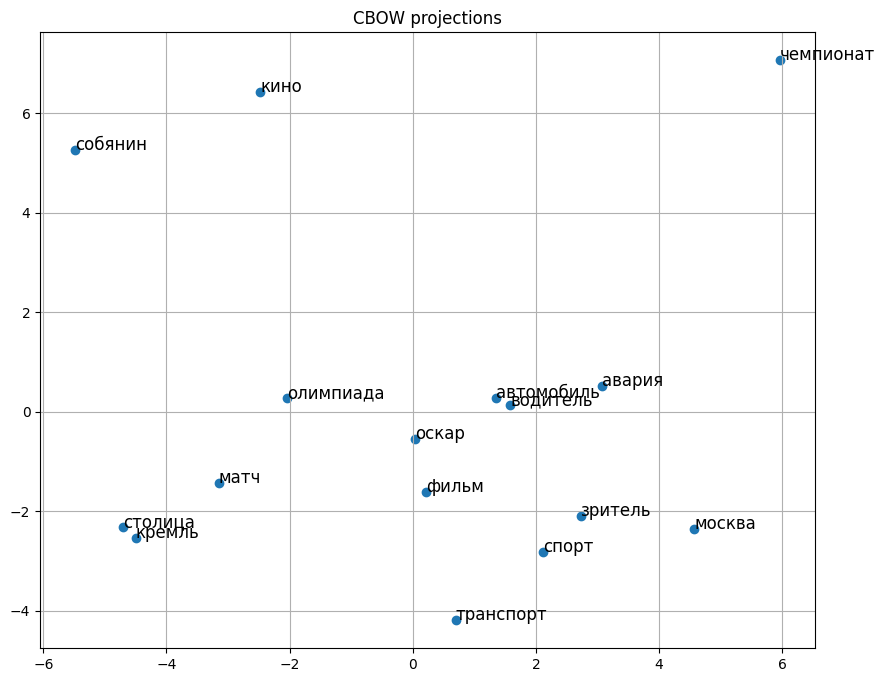

In [ ]:
words_to_plot = ['автомобиль', 'водитель', 'транспорт', 'авария',
                  'москва', 'собянин', 'столица', 'кремль',
                  'олимпиада', 'спорт', 'чемпионат', 'матч',
                  'кино', 'фильм', 'зритель', 'оскар']

print(f"{Fore.RED}Визуализация CBOW эмбеддингов:{Style.RESET_ALL}")
plot_embeddings(cbow_emb, words_to_plot, "CBOW projections")

#print(f"{Fore.RED}Визуализация Skip-Gram эмбеддингов:{Style.RESET_ALL}")
#plot_embeddings(sg_emb, words_to_plot, "Skip-Gram projections")

### 7.2 Коллокаты и части речи

Используем нашу PoS-разметку, чтобы посмотреть, слова каких частей речи чаще всего являются ближайшими соседями для существительных и глаголов.

In [ ]:
# Функция для получения коллокатов
def get_collocates(embeddings_obj, word, tag_dict, k=10):
    similar = embeddings_obj.most_similar(word, k=k)
    result = []
    for sim_word, score in similar:
        pos = tag_dict.get(sim_word, ('UNK', None))[0]
        result.append((sim_word, pos, score))
    return result

word = 'президент'
colls = get_collocates(sg_emb, word, train_tag_dict, k=15)
print(f"{Fore.RED}Коллокаты для '{word}' (Skip-Gram):{Style.RESET_ALL}")
for word, pos, score in colls:
    print(f"{word} ({pos}) : {score:.4f}")

Коллокаты для 'президент' (Skip-Gram):
краткосрочную (ADJ) : 0.6570
проживали (VERB) : 0.6516
кинематографа (NOUN) : 0.6510
дональд (UNK) : 0.6487
экс (UNK) : 0.6459
сербский (UNK) : 0.6396
арменией (UNK) : 0.6385
суверенитету (NOUN) : 0.6366
обвинил (VERB) : 0.6360
порошенко (UNK) : 0.6352
руководители (NOUN) : 0.6322
недовольны (ADJ) : 0.6311
провинции (NOUN) : 0.6284
технически (ADV) : 0.6284
действующий (VERB) : 0.6279


# Аналитическая часть: эксперимент

Гиперпараметры Skim-Gram: window size = 1, embedding size = 50
Урезанный датасет для Skip-Gram: 202124 пар
Epoch 1, Loss: 0.8872

Среднее сходство между словами ['карантин', 'самоизоляция', 'удаленный', 'закрытие']:
-0.0201

Визуализация эмбеддингов:


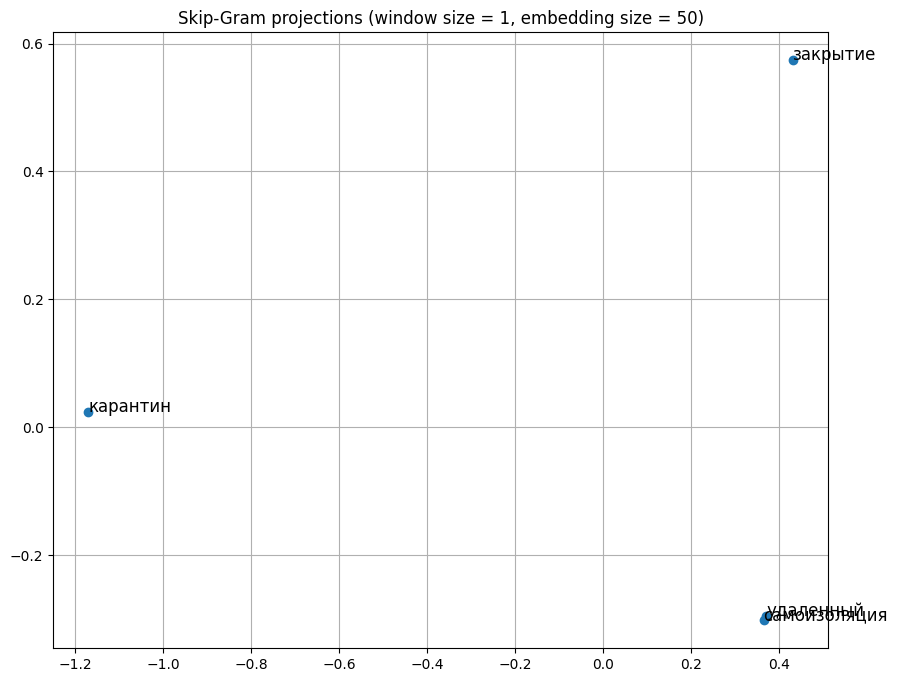

Гиперпараметры Skim-Gram: window size = 1, embedding size = 100
Урезанный датасет для Skip-Gram: 202124 пар
Epoch 1, Loss: 0.8474

Среднее сходство между словами ['карантин', 'самоизоляция', 'удаленный', 'закрытие']:
0.0626

Визуализация эмбеддингов:


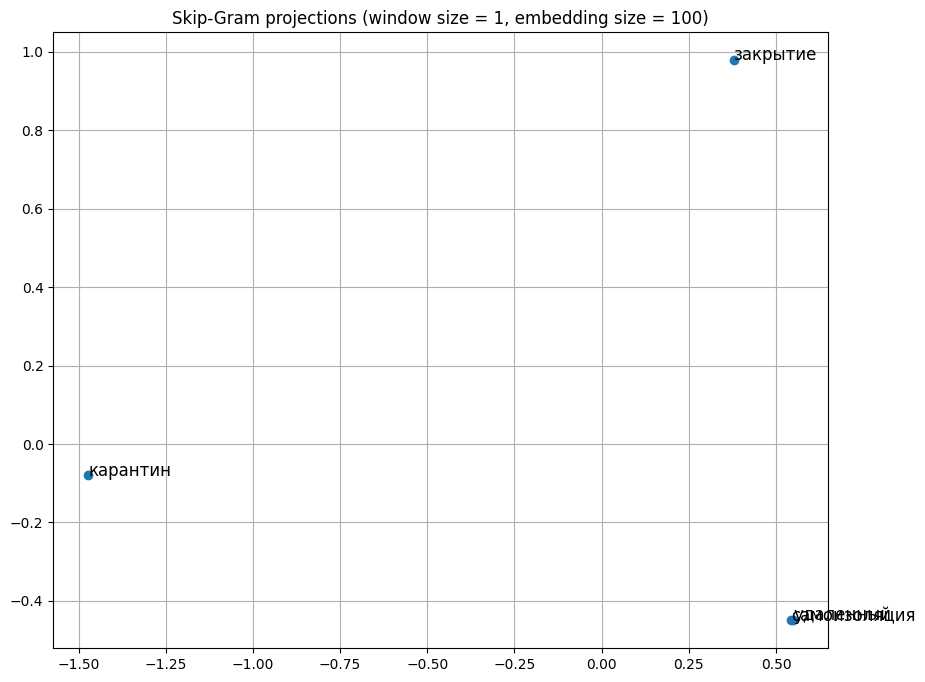

Гиперпараметры Skim-Gram: window size = 1, embedding size = 200
Урезанный датасет для Skip-Gram: 202124 пар
Epoch 1, Loss: 0.8258

Среднее сходство между словами ['карантин', 'самоизоляция', 'удаленный', 'закрытие']:
-0.0166

Визуализация эмбеддингов:


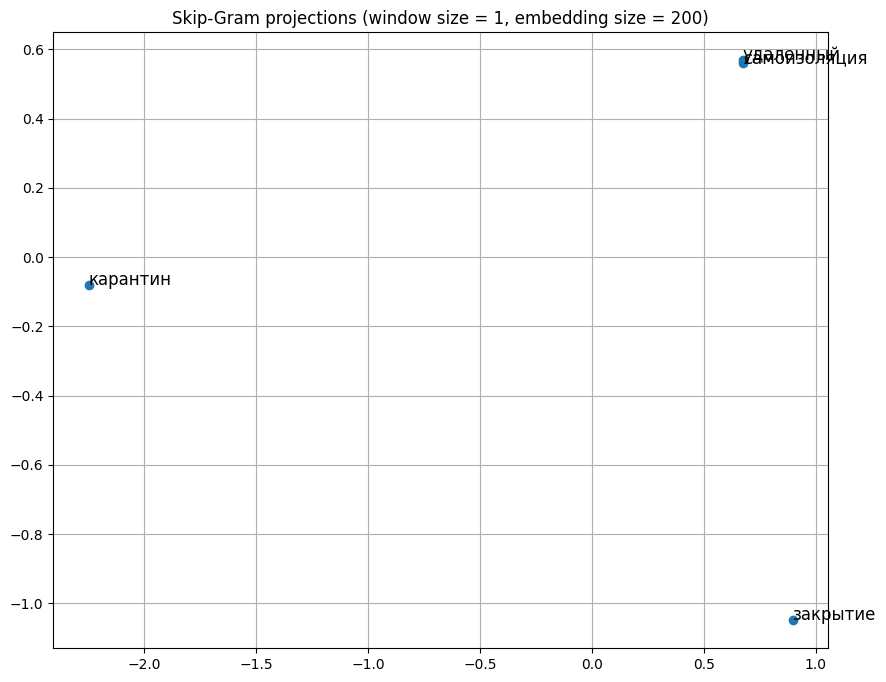

Гиперпараметры Skim-Gram: window size = 3, embedding size = 50
Урезанный датасет для Skip-Gram: 600372 пар
Epoch 1, Loss: 0.8702

Среднее сходство между словами ['карантин', 'самоизоляция', 'удаленный', 'закрытие']:
-0.0075

Визуализация эмбеддингов:


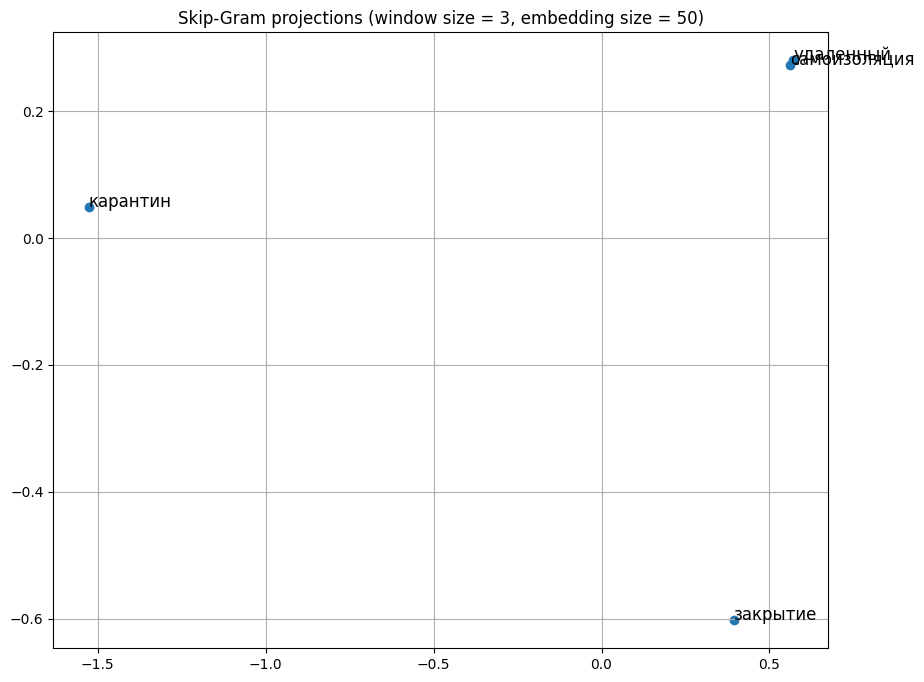

Гиперпараметры Skim-Gram: window size = 3, embedding size = 100
Урезанный датасет для Skip-Gram: 600372 пар
Epoch 1, Loss: 0.8416

Среднее сходство между словами ['карантин', 'самоизоляция', 'удаленный', 'закрытие']:
0.1158

Визуализация эмбеддингов:


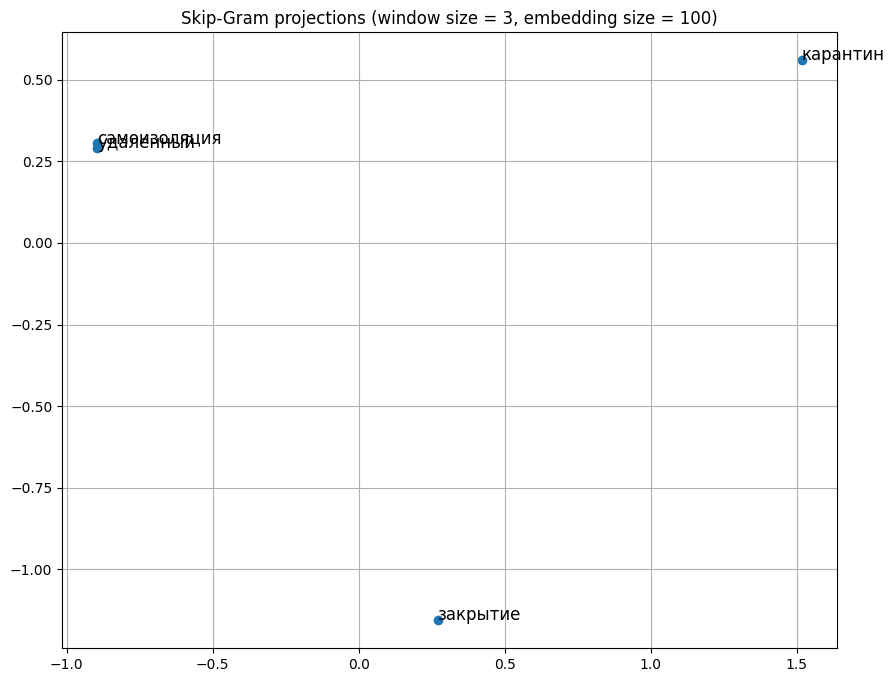

Гиперпараметры Skim-Gram: window size = 3, embedding size = 200
Урезанный датасет для Skip-Gram: 600372 пар
Epoch 1, Loss: 0.8194

Среднее сходство между словами ['карантин', 'самоизоляция', 'удаленный', 'закрытие']:
-0.0066

Визуализация эмбеддингов:


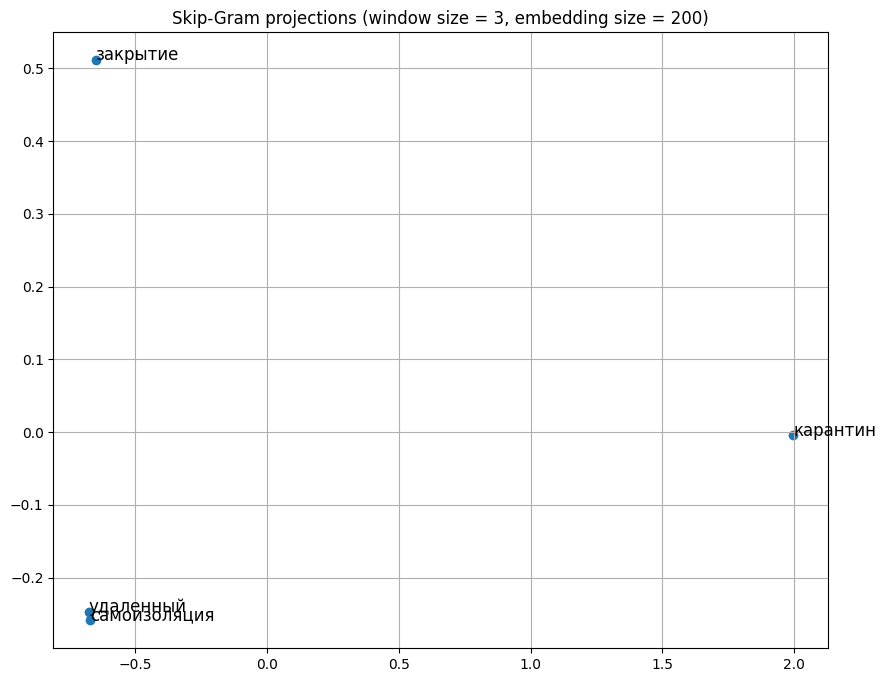

Гиперпараметры Skim-Gram: window size = 5, embedding size = 50
Урезанный датасет для Skip-Gram: 990620 пар
Epoch 1, Loss: 0.8637

Среднее сходство между словами ['карантин', 'самоизоляция', 'удаленный', 'закрытие']:
0.0712

Визуализация эмбеддингов:


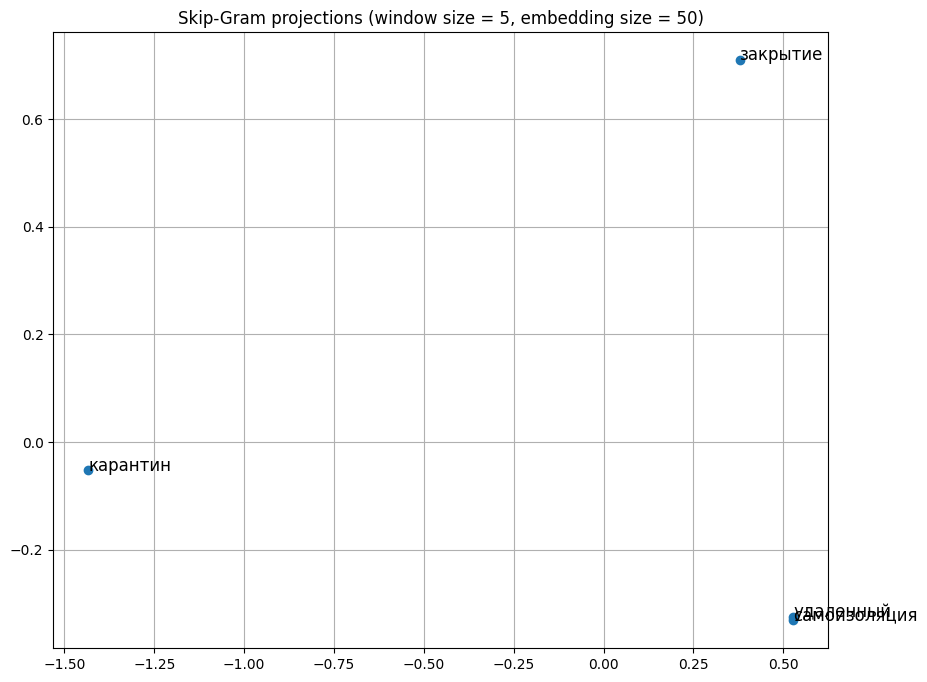

Гиперпараметры Skim-Gram: window size = 5, embedding size = 100
Урезанный датасет для Skip-Gram: 990620 пар
Epoch 1, Loss: 0.8384

Среднее сходство между словами ['карантин', 'самоизоляция', 'удаленный', 'закрытие']:
0.0756

Визуализация эмбеддингов:


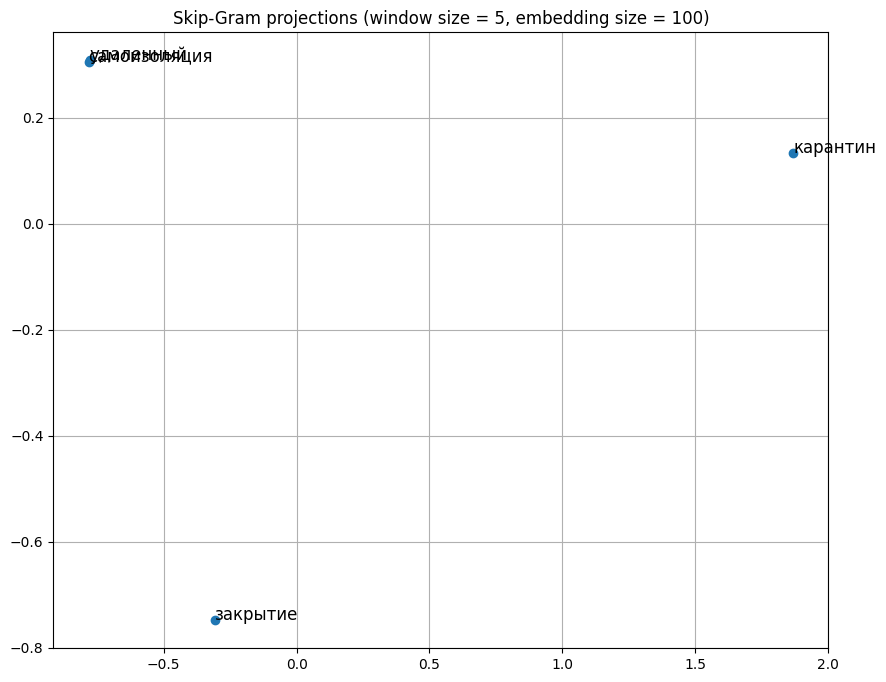

Гиперпараметры Skim-Gram: window size = 5, embedding size = 200
Урезанный датасет для Skip-Gram: 990620 пар
Epoch 1, Loss: 0.8132

Среднее сходство между словами ['карантин', 'самоизоляция', 'удаленный', 'закрытие']:
0.0196

Визуализация эмбеддингов:


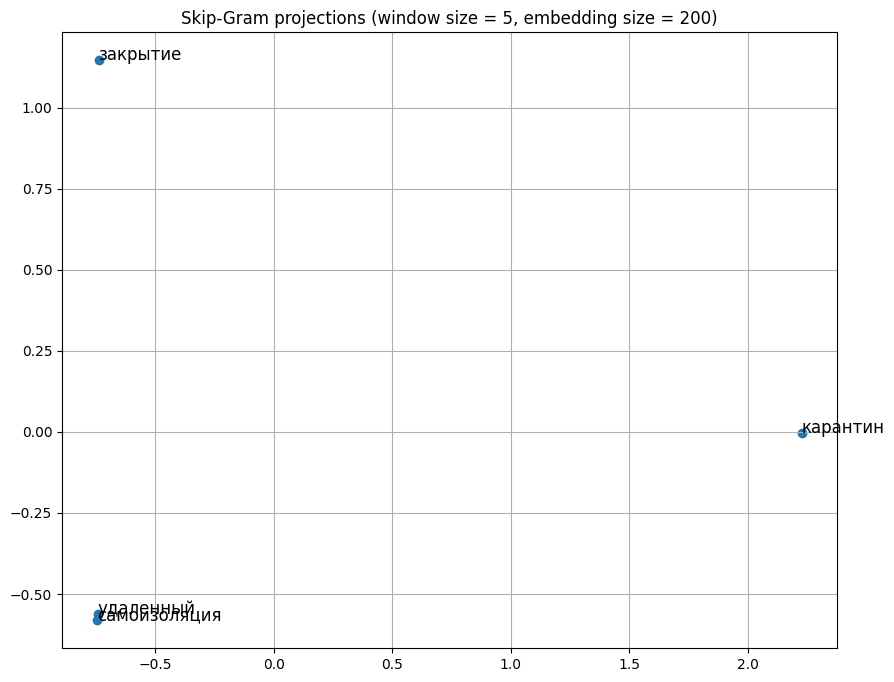

In [ ]:
# Гиперпараметры для Skip-Gram
WINDOW_SIZES = [1, 3, 5]
NEG_SAMPLES = 5
EMB_DIM_SGS = [50, 100, 200]
EPOCHS_SG = 1

words_to_plot = ['карантин', 'самоизоляция', 'удаленный', 'закрытие']

# Итерация по размерам контекстного окна и размерностям эмбеддингов
for WINDOW_SIZE in WINDOW_SIZES:
    for EMB_DIM_SG in EMB_DIM_SGS:
        print(f"{Fore.MAGENTA}Гиперпараметры Skim-Gram: window size = {WINDOW_SIZE}, embedding size = {EMB_DIM_SG}{Style.RESET_ALL}")

        sg_dataset = SkipGramDataset(train_ids[:1000], WINDOW_SIZE, NEG_SAMPLES, vocab_size)
        print(f"{Fore.GREEN}Урезанный датасет для Skip-Gram: {len(sg_dataset)} пар{Style.RESET_ALL}")

        sg_model = SkipGramNegSampling(vocab_size, EMB_DIM_SG)

        sg_model = train_skipgram(sg_model, sg_dataset, epochs=EPOCHS_SG, batch_size=512,
                                device=device, max_batches=300)

        sg_emb = WordEmbeddings(sg_model.center_emb.weight.detach().cpu().numpy(), word2id)

        # Выводим ср. значение косинусного сходства для набора слов
        print(f"\n{Fore.BLUE}Среднее сходство между словами {words_to_plot}:\n{sg_emb.avg_similarity(words_to_plot):.4f}{Style.RESET_ALL}")

        # Визуализируем эмбеддинги с помощью PCA
        print(f"\n{Fore.RED}Визуализация эмбеддингов:{Style.RESET_ALL}")
        plot_embeddings(sg_emb, words_to_plot, f"Skip-Gram projections (window size = {WINDOW_SIZE}, embedding size = {EMB_DIM_SG})")